# Elastic Net Logistic Classification — Stock Direction Prediction & Ranking

## Objective

The objective of this notebook is to build an Elastic Net Logistic Classification model that predicts whether a stock’s next 7-day return will be positive or negative.

This model is used to support:

- stock direction prediction
- buy/avoid decision support
- weekly stock ranking
- portfolio simulation
- comparison with other models such as Random Forest, XGBoost, ARIMA, and LSTM

Unlike regression models that predict the exact return value, this classification model predicts direction:

- 1 = positive next 7-day return
- 0 = negative or zero next 7-day return

This makes the output easier to connect with investment decisions.

In [ ]:
# Import libraries for data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Import library for plotting and visualization
import matplotlib.pyplot as plt

# Import preprocessing and model tools
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Ignore warnings for cleaner notebook outputs
import warnings
warnings.filterwarnings("ignore")

## Configuration

This section defines the data folder path and the stock files used in the model.

The model uses multiple stock datasets so it can learn patterns across different companies and sectors.

In [6]:
# Set path to the project data folder
# This notebook is inside work/Models, so we go two levels up to the project root
DATA_PATH = Path.cwd().parents[1] / "data"

# Check if the data path exists
print("Data path:", DATA_PATH)
print("Data path exists:", DATA_PATH.exists())

# Dictionary mapping stock tickers to file names
stock_files = {
    "AAPL": "Apple.csv",
    "AMZN": "Amazon.csv",
    "GOOGL": "Google.csv",
    "MSFT": "MSFT.csv",
    "NVDA": "NVIDIA.csv",
    "BA": "BA.csv",
    "CVX": "CVX.csv",
    "GS": "GSach.csv",
    "JNJ": "JNJ.csv",
    "JPM": "JPM.csv",
    "META": "META.csv",
    "PFE": "PFE.csv",
    "TSLA": "TSLA.csv",
    "WMT": "WMT.csv",
    "XOM": "XOM.csv"
}

# Check number of datasets
print("Number of stock datasets:", len(stock_files))

# Quick check: show first few CSV files found in the data folder
print("Sample files:", list(DATA_PATH.glob("*.csv"))[:5])

Data path: c:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects\data
Data path exists: True
Number of stock datasets: 15
Sample files: [WindowsPath('c:/Users/POORVI NIDSOSHI/Desktop/Project-ML/group-project-algorithm-architects/data/Amazon.csv'), WindowsPath('c:/Users/POORVI NIDSOSHI/Desktop/Project-ML/group-project-algorithm-architects/data/Apple.csv'), WindowsPath('c:/Users/POORVI NIDSOSHI/Desktop/Project-ML/group-project-algorithm-architects/data/BA.csv'), WindowsPath('c:/Users/POORVI NIDSOSHI/Desktop/Project-ML/group-project-algorithm-architects/data/CVX.csv'), WindowsPath('c:/Users/POORVI NIDSOSHI/Desktop/Project-ML/group-project-algorithm-architects/data/Google.csv')]


## Load Raw Data and Engineer Features

Each stock dataset is loaded separately, cleaned, and converted into a feature-rich dataframe.

The target variable is based on the next 7-day return:

- 1 if next 7-day return is positive
- 0 if next 7-day return is zero or negative

In [15]:
def create_features(df):
    """
    Create return, moving average, volatility, momentum,
    and volume-based features for one stock dataframe.
    """
    
    # Copy dataframe to avoid modifying original data
    df = df.copy()
    
    # Clean column names
    df.columns = df.columns.str.replace('\xa0', '', regex=False).str.strip()
    
    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])
    
    # Convert price and volume columns to numeric
    # This removes commas from values like "212,818,400"
    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Sort by date to preserve time-series order
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Create return features
    df["return_1d"] = df["Close"].pct_change(1)
    df["return_5d"] = df["Close"].pct_change(5)
    df["return_10d"] = df["Close"].pct_change(10)
    
    # Create moving averages
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_10"] = df["Close"].rolling(10).mean()
    df["ma_20"] = df["Close"].rolling(20).mean()
    
    # Create price-to-moving-average ratios
    df["price_to_ma_5"] = df["Close"] / df["ma_5"]
    df["price_to_ma_10"] = df["Close"] / df["ma_10"]
    df["price_to_ma_20"] = df["Close"] / df["ma_20"]
    
    # Create volatility features
    df["volatility_5"] = df["return_1d"].rolling(5).std()
    df["volatility_10"] = df["return_1d"].rolling(10).std()
    
    # Create momentum features
    df["momentum_5"] = df["Close"] / df["Close"].shift(5) - 1
    df["momentum_10"] = df["Close"] / df["Close"].shift(10) - 1
    
    # Create volume ratio feature
    df["volume_ratio_5"] = df["Volume"] / df["Volume"].rolling(5).mean()
    
    # Create actual next 7-day return
    df["target_7d_return"] = df["Close"].shift(-7) / df["Close"] - 1
    
    # Create classification target
    # 1 = positive future return, 0 = zero or negative future return
    df["target_direction"] = (df["target_7d_return"] > 0).astype(int)
    
    return df

## Combine All Stock Datasets

All stock datasets are processed using the same feature engineering function and then combined into one modeling dataframe.

This allows the Elastic Net model to learn from all stocks together.

In [16]:
# List to store processed stock dataframes
all_stock_dfs = []

# Loop through every stock file
for ticker, file_name in stock_files.items():
    
    # Create full file path
    file_path = DATA_PATH / file_name
    
    # Load CSV file
    df = pd.read_csv(file_path)
    
    # Clean column names
    df.columns = df.columns.str.replace('\xa0', '', regex=False).str.strip()
    
    # Add stock ticker column
    df["Stock"] = ticker
    
    # Create features
    df = create_features(df)
    
    # Store processed dataframe
    all_stock_dfs.append(df)

# Combine all stocks into one dataframe
model_df = pd.concat(all_stock_dfs, ignore_index=True)

# Remove missing values created by rolling windows and future target shifting
model_df = model_df.dropna().reset_index(drop=True)

# Preview combined data
model_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock,return_1d,return_5d,...,price_to_ma_5,price_to_ma_10,price_to_ma_20,volatility_5,volatility_10,momentum_5,momentum_10,volume_ratio_5,target_7d_return,target_direction
0,2015-01-30,29.60,30.00,29.21,29.29,25.95,334982000.0,AAPL,-0.014800,0.036814,...,1.021269,1.043017,1.058911,0.036557,0.026247,0.036814,0.097004,0.898860,0.041311,1
1,2015-02-02,29.51,29.79,29.02,29.66,26.27,250956400.0,AAPL,0.012632,0.049169,...,1.024242,1.044440,1.067790,0.036369,0.025553,0.049169,0.119245,0.663251,0.052596,1
2,2015-02-03,29.63,29.77,29.40,29.66,26.28,207662800.0,AAPL,0.000000,0.087243,...,1.007678,1.035398,1.061865,0.027869,0.025273,0.087243,0.091244,0.604636,0.065745,1
3,2015-02-04,29.63,30.13,29.58,29.89,26.48,280598800.0,AAPL,0.007755,0.036767,...,1.008230,1.034399,1.063777,0.016899,0.025273,0.036767,0.091274,0.993660,0.062897,1
4,2015-02-05,30.00,30.06,29.81,29.99,26.67,168984800.0,AAPL,0.003346,0.008745,...,1.009832,1.031116,1.061574,0.010416,0.024599,0.008745,0.067260,0.679645,0.065689,1


## Feature Columns and Target

The model uses return, momentum, volatility, moving-average, and volume-based features.

The target variable is `target_direction`, which indicates whether the next 7-day return is positive.

In [17]:
# Define input feature columns
feature_cols = [
    "return_1d",
    "return_5d",
    "return_10d",
    "price_to_ma_5",
    "price_to_ma_10",
    "price_to_ma_20",
    "volatility_5",
    "volatility_10",
    "momentum_5",
    "momentum_10",
    "volume_ratio_5"
]

# Define classification target column
target_col = "target_direction"

## Explore Target Direction Distribution

Before training, we check how many observations are positive-return cases and non-positive-return cases.

This helps us understand whether the classification target is balanced.

target_direction
0    17338
1    21894
Name: count, dtype: int64


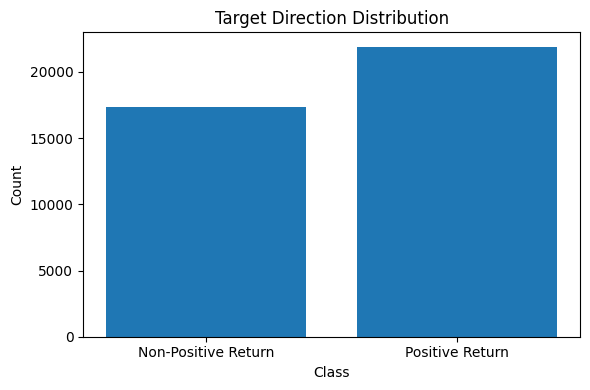

In [18]:
# Count target classes
direction_counts = model_df[target_col].value_counts().sort_index()

# Display class distribution
print(direction_counts)

# Plot target distribution
plt.figure(figsize=(6, 4))
plt.bar(["Non-Positive Return", "Positive Return"], direction_counts.values)
plt.title("Target Direction Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Conclusion: Target Direction Distribution

The distribution of the target variable shows that both classes — positive returns and non-positive returns — are relatively balanced, with a slightly higher number of positive return observations.

This indicates that:

The dataset does not suffer from severe class imbalance, which is beneficial for training a classification model.
The model will not be biased toward one class (e.g., always predicting positive or negative returns).
The learning process will be more stable and reliable compared to highly imbalanced datasets.

From an investment perspective:

The slight dominance of positive returns suggests that the market has an overall upward trend during the observed period.
However, the presence of a substantial number of non-positive returns confirms that downside risk exists, making prediction meaningful and non-trivial.

## Time-Based Train, Validation, and Test Split

Because this is time-series stock data, we do not randomly shuffle the data.

We use a strict temporal split:
- Training: before 2024
- Validation: 2024
- Testing: 2025 onward

This avoids data leakage.

In [19]:
# Sort by date
model_df = model_df.sort_values("Date").reset_index(drop=True)

# Create time-based splits
train_df = model_df[model_df["Date"] < "2024-01-01"]

val_df = model_df[
    (model_df["Date"] >= "2024-01-01") &
    (model_df["Date"] < "2025-01-01")
]

test_df = model_df[model_df["Date"] >= "2025-01-01"]

# Separate features and target
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Print split sizes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (31719, 11)
Validation: (3539, 11)
Test: (3974, 11)


## Train Elastic Net Logistic Classification Model

Elastic Net Logistic Classification combines L1 and L2 regularization.

This helps reduce overfitting while keeping the model interpretable through coefficients.

In [20]:
# Create Elastic Net Logistic Classification pipeline
# StandardScaler is used because logistic regression is sensitive to feature scale
elastic_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=10000,
        random_state=42
    ))
])

# Train model
elastic_logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(l1_ratio=0.5, max_iter=10000,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

The Elastic Net Logistic Regression model predicts whether a stock's 7-day return will be positive or negative. By combining L1 and L2 regularization (l1_ratio=0.5), it handles correlated features effectively while preventing overfitting. StandardScaler ensures all features are on the same scale. This classification approach provides a simple, actionable buy/no-buy signal for investment decisions.

## Validation Evaluation

We evaluate the model on the validation set using classification metrics.

Metrics include:
- accuracy
- precision
- recall
- F1 score

In [21]:
# Predict validation class labels
val_preds = elastic_logistic_model.predict(X_val)

# Predict probability of positive return
val_probs = elastic_logistic_model.predict_proba(X_val)[:, 1]

# Calculate validation metrics
val_accuracy = accuracy_score(y_val, val_preds)
val_precision = precision_score(y_val, val_preds, zero_division=0)
val_recall = recall_score(y_val, val_preds, zero_division=0)
val_f1 = f1_score(y_val, val_preds, zero_division=0)

# Print validation metrics
print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1:", val_f1)

Validation Accuracy: 0.5597626448149194
Validation Precision: 0.5599208592425099
Validation Recall: 0.9994954591321897
Validation F1: 0.7177536231884057


## Test Evaluation

After validation, we evaluate the model on the unseen test set from 2025 onward.

This gives the final performance estimate.

In [22]:
# Predict test class labels
test_preds = elastic_logistic_model.predict(X_test)

# Predict probability of positive return
test_probs = elastic_logistic_model.predict_proba(X_test)[:, 1]

# Calculate test metrics
test_accuracy = accuracy_score(y_test, test_preds)
test_precision = precision_score(y_test, test_preds, zero_division=0)
test_recall = recall_score(y_test, test_preds, zero_division=0)
test_f1 = f1_score(y_test, test_preds, zero_division=0)

# Print test metrics
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)

Test Accuracy: 0.5742325113236034
Test Precision: 0.5742325113236034
Test Recall: 1.0
Test F1: 0.729539641943734


## Save Predictions

We create a prediction dataframe containing:
- Date
- Stock
- Actual Return
- Actual Direction
- Predicted Direction
- Predicted Probability

This output will be used for ranking and investment simulation.

In [23]:
# Create prediction dataframe from test set
elastic_predictions_df = test_df[
    ["Date", "Stock", "target_7d_return", "target_direction"]
].copy()

# Add predicted direction
elastic_predictions_df["Predicted Direction"] = test_preds

# Add probability of positive return
elastic_predictions_df["Predicted Probability"] = test_probs

# Rename columns for readability
elastic_predictions_df = elastic_predictions_df.rename(columns={
    "target_7d_return": "Actual Return",
    "target_direction": "Actual Direction"
})

# Preview predictions
elastic_predictions_df.head()

,Date,Stock,Actual Return,Actual Direction,Predicted Direction,Predicted Probability
35258,2025-01-02,JPM,0.031125,1,1,0.554667
35259,2025-01-02,MSFT,-0.006952,0,1,0.557706
35260,2025-01-02,TSLA,0.045033,1,1,0.603385
35261,2025-01-02,JNJ,0.005069,1,1,0.552124
35262,2025-01-02,XOM,0.022458,1,1,0.549663


In [25]:
# Save predictions to CSV
elastic_predictions_df.to_csv("elastic_net_logistic_predictions.csv", index=False)

print("Saved elastic_net_logistic_predictions.csv")

Saved elastic_net_logistic_predictions.csv


## Accuracy Summary by Stock

We evaluate performance separately for each stock.

This helps identify which stocks the model predicts better and which stocks are harder to classify.

In [26]:
# Store stock-wise metric results
summary_rows = []

# Loop through each stock
for stock in elastic_predictions_df["Stock"].unique():
    
    # Filter rows for one stock
    temp = elastic_predictions_df[elastic_predictions_df["Stock"] == stock]
    
    # Calculate metrics
    acc = accuracy_score(temp["Actual Direction"], temp["Predicted Direction"])
    prec = precision_score(temp["Actual Direction"], temp["Predicted Direction"], zero_division=0)
    rec = recall_score(temp["Actual Direction"], temp["Predicted Direction"], zero_division=0)
    f1 = f1_score(temp["Actual Direction"], temp["Predicted Direction"], zero_division=0)
    
    # Save results
    summary_rows.append({
        "Stock": stock,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

# Convert to dataframe
elastic_summary_df = pd.DataFrame(summary_rows)

# Display summary
elastic_summary_df

,Stock,Accuracy,Precision,Recall,F1 Score
0,JPM,0.627660,0.627660,1.0,0.771242
1,MSFT,0.514184,0.514184,1.0,0.679157
2,TSLA,0.514184,0.514184,1.0,0.679157
3,JNJ,0.695035,0.695035,1.0,0.820084
4,XOM,0.606383,0.606383,1.0,0.754967
5,AAPL,0.535461,0.535461,1.0,0.697460
6,AMZN,0.528369,0.528369,1.0,0.691415
7,BA,0.585106,0.585106,1.0,0.738255
8,PFE,0.503546,0.503546,1.0,0.669811
9,GS,0.564356,0.564356,1.0,0.721519


## Buy / Avoid Signals

The model output is converted into a simple decision signal:

- BUY: predicted positive next 7-day return
- AVOID: predicted non-positive next 7-day return

This helps make the model output more useful for investors.

In [28]:
# Create BUY / AVOID signal based on predicted direction
elastic_predictions_df["Signal"] = np.where(
    elastic_predictions_df["Predicted Direction"] == 1,
    "BUY",
    "AVOID"
)

# Preview signals
elastic_predictions_df.head()

,Date,Stock,Actual Return,Actual Direction,Predicted Direction,Predicted Probability,Signal
35258,2025-01-02,JPM,0.031125,1,1,0.554667,BUY
35259,2025-01-02,MSFT,-0.006952,0,1,0.557706,BUY
35260,2025-01-02,TSLA,0.045033,1,1,0.603385,BUY
35261,2025-01-02,JNJ,0.005069,1,1,0.552124,BUY
35262,2025-01-02,XOM,0.022458,1,1,0.549663,BUY


## Confusion Matrix

The confusion matrix shows how often the model correctly or incorrectly predicts stock direction.

It compares actual direction against predicted direction.

In [29]:
# Create confusion matrix for test predictions
cm = confusion_matrix(y_test, test_preds)

# Display confusion matrix as dataframe
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df

,Predicted 0,Predicted 1
Actual 0,0,1692
Actual 1,0,2282


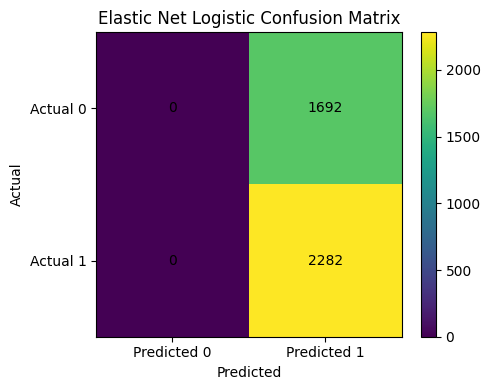

In [30]:
# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, aspect="auto")
plt.title("Elastic Net Logistic Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# Add values inside matrix cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.tight_layout()
plt.show()

## Predicted Probability Over Time

This plot shows how the model’s predicted probability of positive return changes over time.

It helps visualize how confident the model is across the test period.

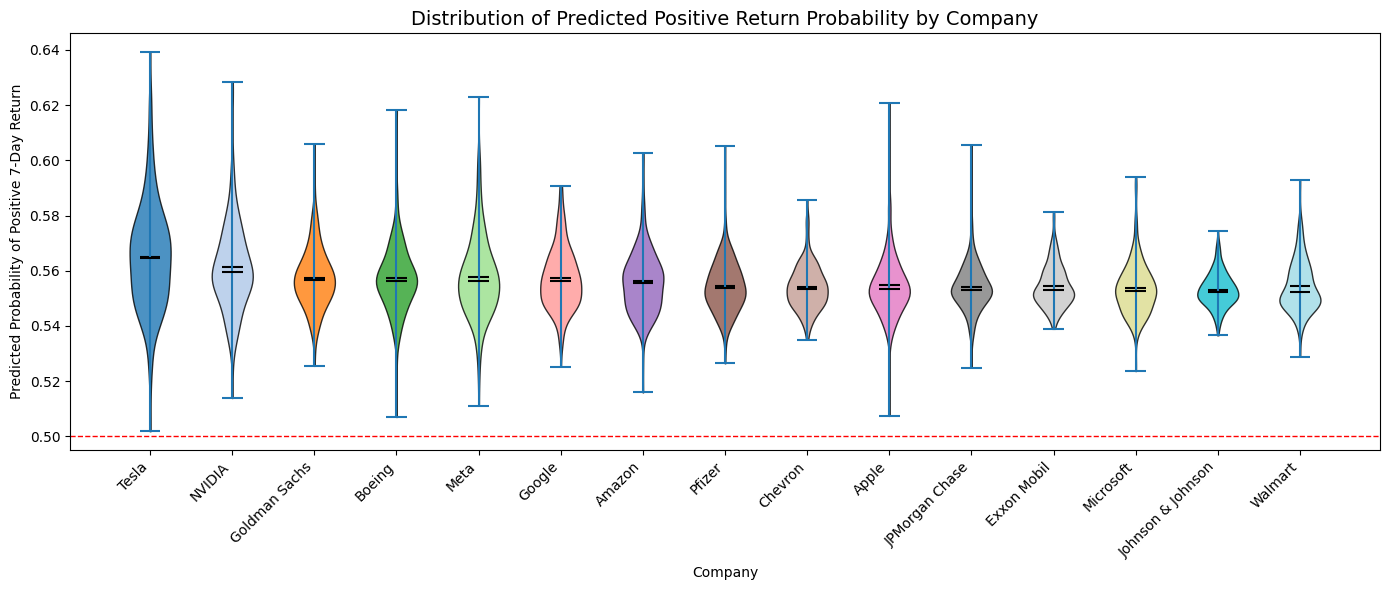

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

violin = plt.violinplot(
    data_to_plot,
    showmeans=True,
    showmedians=True
)

# Create different colors
colors = plt.cm.tab20(np.linspace(0, 1, len(data_to_plot)))

# Apply colors to each violin
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.8)

# Style mean & median lines
for part in ['cmeans', 'cmedians']:
    if part in violin:
        violin[part].set_color('black')

# Add decision boundary line
plt.axhline(0.50, linestyle="--", color="red", linewidth=1)

plt.title("Distribution of Predicted Positive Return Probability by Company", fontsize=14)
plt.xlabel("Company")
plt.ylabel("Predicted Probability of Positive 7-Day Return")

plt.xticks(
    ticks=range(1, len(company_order) + 1),
    labels=company_order,
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## Interpretation

This violin plot compares the distribution of predicted positive 7-day return probability across all companies.

Most companies have predicted probabilities above the 0.50 decision boundary, meaning the Elastic Net Logistic model generally expects positive returns across the test period.

Tesla and NVIDIA show higher and wider distributions, which means the model often gives them stronger positive-return probabilities and more variation over time.

Companies like Johnson & Johnson, Exxon Mobil, Walmart, and Microsoft have tighter distributions, meaning the model’s predictions for these companies are more stable but less aggressive.

Overall, the chart shows that the model tends to favor growth-oriented companies such as Tesla and NVIDIA, while giving more moderate confidence to defensive or stable companies.

However, because most companies are clustered close to each other around 0.55, the model does not strongly separate winners from weaker stocks. This supports the conclusion that Elastic Net is useful for interpretation, but more complex models like XGBoost may be better for final ranking and investment decisions.

## Weekly Stock Rankings

Stocks are ranked by predicted probability of positive return.

The stock with rank 1 is the strongest predicted opportunity for that date.

In [32]:
# Rank stocks by predicted probability for each date
elastic_predictions_df["Rank"] = elastic_predictions_df.groupby("Date")[
    "Predicted Probability"
].rank(ascending=False, method="first")

# Sort by date and rank
elastic_predictions_df = elastic_predictions_df.sort_values(
    ["Date", "Rank"]
).reset_index(drop=True)

# Preview ranking output
elastic_predictions_df.head(15)

,Date,Stock,Actual Return,Actual Direction,Predicted Direction,Predicted Probability,Signal,Rank
0,2025-01-02,TSLA,0.045033,1,1,0.603385,BUY,1.0
1,2025-01-02,BA,-0.028219,0,1,0.565826,BUY,2.0
2,2025-01-02,GOOGL,0.001214,1,1,0.564613,BUY,3.0
3,2025-01-02,AAPL,-0.043346,0,1,0.563010,BUY,4.0
4,2025-01-02,AMZN,-0.011171,0,1,0.559942,BUY,5.0
5,2025-01-02,PFE,-0.007516,0,1,0.558009,BUY,6.0
6,2025-01-02,MSFT,-0.006952,0,1,0.557706,BUY,7.0
7,2025-01-02,GS,-0.005983,0,1,0.555816,BUY,8.0
8,2025-01-02,JPM,0.031125,1,1,0.554667,BUY,9.0
9,2025-01-02,NVDA,-0.047357,0,1,0.553800,BUY,10.0


## Barchart

The Barchart  shows how each stock ranks across different dates.

Lower rank values indicate stronger model recommendations.

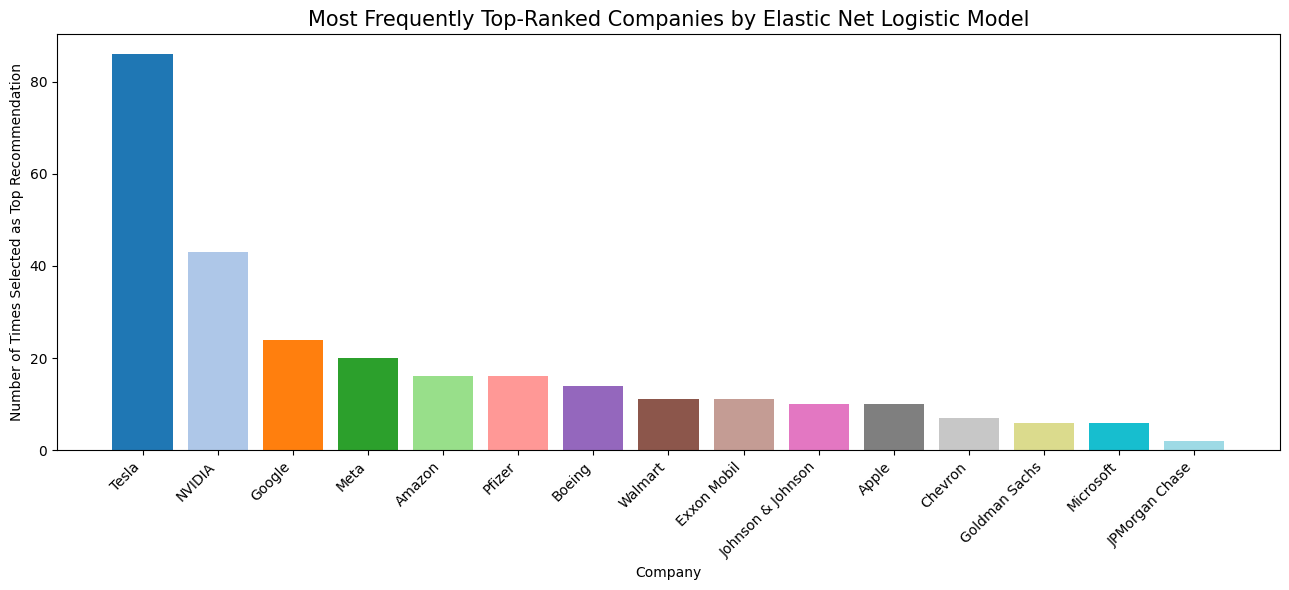

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Select only the top-ranked stock for each date
top_ranked_elastic = elastic_predictions_df[
    elastic_predictions_df["Rank"] == 1
].copy()

# Count how many times each stock was ranked #1
top_stock_counts = top_ranked_elastic["Stock"].value_counts()

# Map tickers to company names
company_names = {
    "TSLA": "Tesla",
    "NVDA": "NVIDIA",
    "GOOGL": "Google",
    "META": "Meta",
    "AMZN": "Amazon",
    "PFE": "Pfizer",
    "BA": "Boeing",
    "WMT": "Walmart",
    "XOM": "Exxon Mobil",
    "JNJ": "Johnson & Johnson",
    "AAPL": "Apple",
    "CVX": "Chevron",
    "GS": "Goldman Sachs",
    "MSFT": "Microsoft",
    "JPM": "JPMorgan Chase"
}

# Convert ticker symbols to company names
company_labels = [company_names.get(stock, stock) for stock in top_stock_counts.index]

# Create different colors automatically
colors = plt.cm.tab20(np.linspace(0, 1, len(top_stock_counts)))

# Plot chart
plt.figure(figsize=(13, 6))
plt.bar(company_labels, top_stock_counts.values, color=colors)

plt.title("Most Frequently Top-Ranked Companies by Elastic Net Logistic Model", fontsize=15)
plt.xlabel("Company")
plt.ylabel("Number of Times Selected as Top Recommendation")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Interpretation

This chart shows how often each company was selected as the top-ranked recommendation by the Elastic Net Logistic model.

Tesla was selected most frequently, meaning the model often assigned Tesla the highest probability of having a positive next 7-day return. NVIDIA was the second most frequent top-ranked company, followed by Google and Meta.

This suggests that the model favored high-growth technology stocks more often than companies from sectors such as finance, healthcare, or energy.

However, being ranked #1 frequently does not automatically mean the stock always produced the highest actual return. It only means the model repeatedly viewed that stock as the strongest buy candidate based on predicted probability.

Overall, this chart helps explain the model’s recommendation behavior and shows which companies the model preferred most often.

## Investment Simulation

We simulate investing $10,000 in the top-ranked stock for each date.

The portfolio is updated using the actual realized 7-day return of the selected stock.

This evaluates whether the model’s ranking output is useful for investment decision-making.

In [35]:
# Select top-ranked stock for each date
top_elastic_df = elastic_predictions_df[
    elastic_predictions_df["Rank"] == 1
].copy()

# Set initial investment amount
initial_capital = 10000
capital = initial_capital

# Store portfolio value after each investment step
portfolio_values = []

# Update portfolio using actual return of selected top-ranked stock
for actual_return in top_elastic_df["Actual Return"]:
    capital = capital * (1 + actual_return)
    portfolio_values.append(capital)

# Store portfolio value and cumulative profit/loss
top_elastic_df["Portfolio Value"] = portfolio_values
top_elastic_df["Profit/Loss"] = top_elastic_df["Portfolio Value"] - initial_capital

# Preview simulation
top_elastic_df.head()

,Date,Stock,Actual Return,Actual Direction,Predicted Direction,Predicted Probability,Signal,Rank,Portfolio Value,Profit/Loss
0,2025-01-02,TSLA,0.045033,1,1,0.603385,BUY,1.0,10450.326935,450.326935
13,2025-01-03,TSLA,0.043319,1,1,0.572917,BUY,1.0,10903.028458,903.028458
26,2025-01-06,BA,-0.010833,0,1,0.557381,BUY,1.0,10784.919764,784.919764
39,2025-01-07,NVDA,-0.017340,0,1,0.563699,BUY,1.0,10597.911380,597.911380
52,2025-01-08,NVDA,0.005139,1,1,0.586846,BUY,1.0,10652.372133,652.372133



## Portfolio Performance Summary

This section summarizes the final investment outcome of the Elastic Net Logistic ranking strategy.

The key metrics are:
- initial capital
- final portfolio value
- total profit or loss
- total return percentage

In [36]:
# Calculate final portfolio value
final_value = top_elastic_df["Portfolio Value"].iloc[-1]

# Calculate total profit/loss
total_profit = final_value - initial_capital

# Calculate total return percentage
total_return_pct = (final_value / initial_capital - 1) * 100

# Print summary
print("Initial Capital:", initial_capital)
print("Final Portfolio Value:", round(final_value, 2))
print("Total Profit/Loss:", round(total_profit, 2))
print("Total Return (%):", round(total_return_pct, 2))

Initial Capital: 10000
Final Portfolio Value: 4898.26
Total Profit/Loss: -5101.74
Total Return (%): -51.02


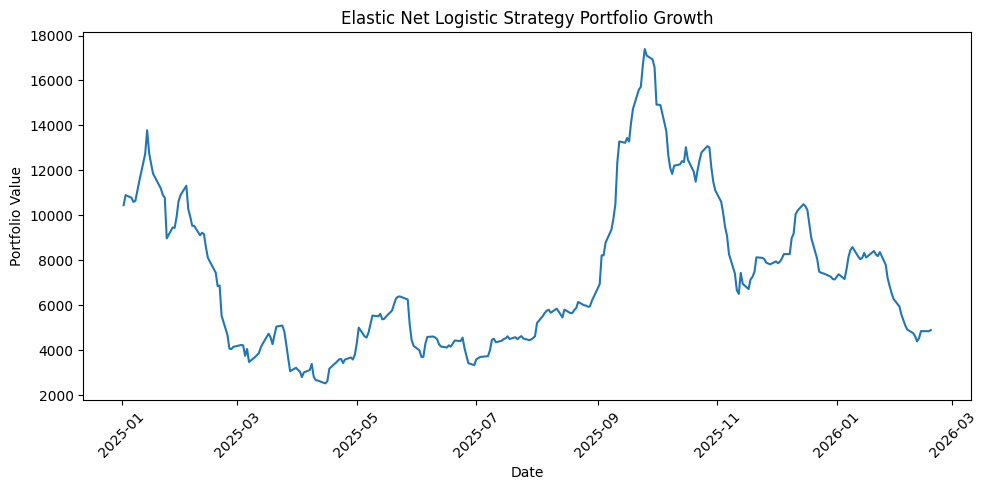

In [37]:
# Plot portfolio growth
plt.figure(figsize=(10, 5))
plt.plot(top_elastic_df["Date"], top_elastic_df["Portfolio Value"])

plt.title("Elastic Net Logistic Strategy Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation

Elastic Net Logistic Classification provides an interpretable directional prediction model.

Instead of predicting the exact return, it predicts whether the stock is expected to move up or not over the next 7 days.

This supports buy/avoid recommendations and stock ranking.

Compared to Random Forest, the key difference is interpretability:
- Random Forest uses tree-based feature importance
- Elastic Net Logistic Classification uses coefficient importance

This model is useful because it shows whether a simpler, regularized classification approach can support investment decisions alongside more complex models.

## Elastic Net Logistic Classification Model Methodology

### Objective
The objective of the Elastic Net Logistic model is to predict whether a stock’s next 7-day return will be positive or not, and support buy/avoid decisions.

### Data Preparation
- Multiple stock datasets were combined into a single dataset
- Data was cleaned and sorted by date
- Time-based splitting was applied to maintain temporal order

### Feature Engineering
The same features used in the XGBoost model were applied:
- Lagged returns
- Moving averages
- Volatility
- Momentum
- Volume-based indicators

### Target Variable
The model predicts:
- 1 = positive next 7-day return
- 0 = non-positive next 7-day return

### Model Training
- Logistic Regression with Elastic Net regularization was used
- StandardScaler was applied to normalize feature values
- Model was trained using time-based train, validation, and test splits

### Evaluation
The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Signal Generation
- BUY signal: predicted positive return
- AVOID signal: predicted non-positive return

### Ranking
- Stocks were ranked based on predicted probability of positive return
- The stock with the highest probability was selected

### Investment Simulation
- A portfolio strategy was simulated using top-ranked stocks
- Portfolio value and profit/loss were calculated

### Purpose
The Elastic Net model provides interpretable predictions and helps investors make simple buy/avoid decisions while understanding feature influence.